**EDA & Pre-Processing**

In [55]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
from PIL import Image
from collections import Counter
import random
import cv2
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn.tree import plot_tree

sns.set_style("whitegrid")

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
for root, dirs, files in os.walk("/content/drive/MyDrive"):
    print(root)
    print(files[:5])
    break

/content/drive/MyDrive
['Getting started.pdf', 'Data Protection Form (Arabic).gdoc', '16634325916845661675284426987286.jpg', '16634326438695431860551494312567.jpg', 'IMG_20221019_185218.jpg']


In [5]:
zip_path = "/content/drive/MyDrive/Data.zip"

extract_path = "/content/Data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [6]:
for root, dirs, files in os.walk("/content/Data"):
    print("FOLDER:", root)
    print("FILES:", files[:5])
    print("-----")

FOLDER: /content/Data
FILES: []
-----
FOLDER: /content/Data/Data
FILES: []
-----
FOLDER: /content/Data/Data/Data
FILES: []
-----
FOLDER: /content/Data/Data/Data/dataset_split
FILES: []
-----
FOLDER: /content/Data/Data/Data/dataset_split/val
FILES: ['val.csv']
-----
FOLDER: /content/Data/Data/Data/dataset_split/val/images
FILES: ['img03263.jpg', 'img05796.jpg', 'img06381.jpg', 'img10969.jpg', 'img16051.jpg']
-----
FOLDER: /content/Data/Data/Data/dataset_split/train
FILES: ['train.csv']
-----
FOLDER: /content/Data/Data/Data/dataset_split/train/images
FILES: ['img05361.jpg', 'img14200.jpg', 'img09087.jpg', 'img05216.jpg', 'img07997.jpg']
-----
FOLDER: /content/Data/Data/Data/dataset_split/test
FILES: ['test.csv']
-----
FOLDER: /content/Data/Data/Data/dataset_split/test/images
FILES: ['img06369.jpg', 'img10117.jpg', 'img03295.jpg', 'img02858.jpg', 'img08806.jpg']
-----


In [7]:
os.listdir("/content/Data")

['Data']

In [8]:
BASE_PATH = "/content/Data/Data/Data/dataset_split"

TRAIN_CSV = f"{BASE_PATH}/train/train.csv"
TRAIN_IMG = f"{BASE_PATH}/train/images"
train_df = pd.read_csv(TRAIN_CSV)

print("Train shape:", train_df.shape)
train_df.head()

Train shape: (13015, 34)


,image_id,patient_id,camera,patient_age,comorbidities,diabetes_time_y,insuline,patient_sex,exam_eye,diabetes,...,amd,vascular_occlusion,hypertensive_retinopathy,drusens,hemorrhage,retinal_detachment,myopic_fundus,increased_cup_disc,other,quality
0,img00001,1,Canon CR,48.0,diabetes1,12,yes,1,1,yes,...,0,0,0,0,0,0,0,1,0,Adequate
1,img00002,1,Canon CR,48.0,diabetes1,12,yes,1,2,yes,...,0,0,0,0,0,0,0,1,0,Adequate
2,img00003,2,Canon CR,18.0,diabetes1,7,yes,2,1,yes,...,0,0,0,0,0,0,0,0,0,Adequate
3,img00004,2,Canon CR,18.0,diabetes1,7,yes,2,2,yes,...,0,0,0,0,0,0,0,0,0,Adequate
4,img00005,3,Canon CR,22.0,diabetes1,11,yes,1,1,yes,...,0,0,0,0,0,0,0,0,0,Adequate


In [9]:
print("Train shape:", train_df.shape)
train_df.head()

Train shape: (13015, 34)


,image_id,patient_id,camera,patient_age,comorbidities,diabetes_time_y,insuline,patient_sex,exam_eye,diabetes,...,amd,vascular_occlusion,hypertensive_retinopathy,drusens,hemorrhage,retinal_detachment,myopic_fundus,increased_cup_disc,other,quality
0,img00001,1,Canon CR,48.0,diabetes1,12,yes,1,1,yes,...,0,0,0,0,0,0,0,1,0,Adequate
1,img00002,1,Canon CR,48.0,diabetes1,12,yes,1,2,yes,...,0,0,0,0,0,0,0,1,0,Adequate
2,img00003,2,Canon CR,18.0,diabetes1,7,yes,2,1,yes,...,0,0,0,0,0,0,0,0,0,Adequate
3,img00004,2,Canon CR,18.0,diabetes1,7,yes,2,2,yes,...,0,0,0,0,0,0,0,0,0,Adequate
4,img00005,3,Canon CR,22.0,diabetes1,11,yes,1,1,yes,...,0,0,0,0,0,0,0,0,0,Adequate


In [10]:
train_df.columns.tolist()

['image_id',
 'patient_id',
 'camera',
 'patient_age',
 'comorbidities',
 'diabetes_time_y',
 'insuline',
 'patient_sex',
 'exam_eye',
 'diabetes',
 'nationality',
 'optic_disc',
 'vessels',
 'macula',
 'DR_SDRG',
 'DR_ICDR',
 'focus',
 'Illuminaton',
 'image_field',
 'artifacts',
 'diabetic_retinopathy',
 'macular_edema',
 'scar',
 'nevus',
 'amd',
 'vascular_occlusion',
 'hypertensive_retinopathy',
 'drusens',
 'hemorrhage',
 'retinal_detachment',
 'myopic_fundus',
 'increased_cup_disc',
 'other',
 'quality']

In [11]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13015 entries, 0 to 13014
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   image_id                  13015 non-null  object 
 1   patient_id                13015 non-null  int64  
 2   camera                    13015 non-null  object 
 3   patient_age               8669 non-null   float64
 4   comorbidities             6396 non-null   object 
 5   diabetes_time_y           1545 non-null   object 
 6   insuline                  1381 non-null   object 
 7   patient_sex               13015 non-null  int64  
 8   exam_eye                  13015 non-null  int64  
 9   diabetes                  13015 non-null  object 
 10  nationality               13015 non-null  object 
 11  optic_disc                13015 non-null  int64  
 12  vessels                   13015 non-null  int64  
 13  macula                    13015 non-null  int64  
 14  DR_SDR

In [12]:
train_df.isna().sum()

,0
image_id,0
patient_id,0
camera,0
patient_age,4346
comorbidities,6619
diabetes_time_y,11470
insuline,11634
patient_sex,0
exam_eye,0
diabetes,0


Total images: 13015


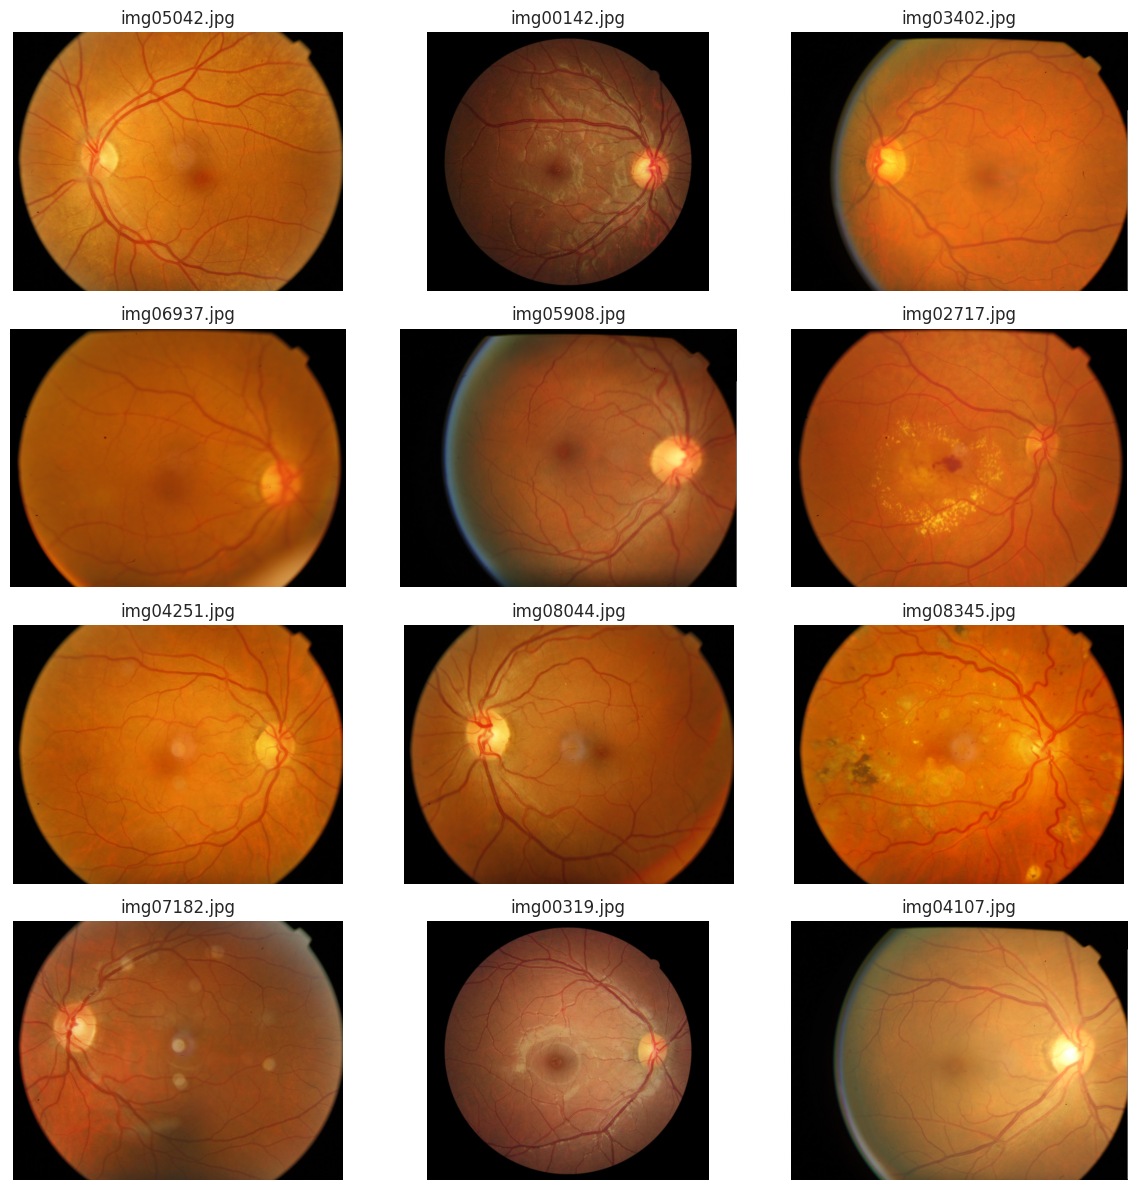

In [54]:
folder = TRAIN_IMG


image_paths = [
    os.path.join(folder, f)
    for f in os.listdir(folder)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
]

print("Total images:", len(image_paths))

sample_paths = random.sample(image_paths, 12)

plt.figure(figsize=(12, 12))

for i, path in enumerate(sample_paths):
    img = cv2.imread(path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(4, 3, i + 1)
    plt.imshow(img_rgb)
    plt.title(os.path.basename(path))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
cols_to_drop_high_nan = [
    "diabetes_time_y",
    "insuline"
]

train_df = train_df.drop(columns=cols_to_drop_high_nan)

print("Dropped columns:", cols_to_drop_high_nan)

Dropped columns: ['diabetes_time_y', 'insuline']


In [14]:
train_df.duplicated().sum()

np.int64(0)

In [15]:
train_df["patient_age"] = pd.to_numeric(train_df["patient_age"], errors="coerce")

age_median = train_df["patient_age"].median()

train_df["patient_age"] = train_df["patient_age"].fillna(age_median)

train_df["comorbidities"] = train_df["comorbidities"].fillna(train_df["comorbidities"].mode()[0])

train_df.isnull().sum().sort_values(ascending=False).head(10)

,0
image_id,0
patient_id,0
camera,0
patient_age,0
comorbidities,0
patient_sex,0
exam_eye,0
diabetes,0
nationality,0
optic_disc,0


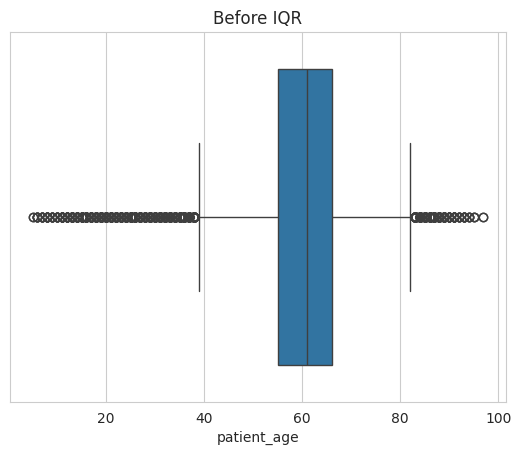

In [16]:
sns.boxplot(x=train_df["patient_age"])
plt.title("Before IQR")
plt.show()

In [17]:
numeric_cols = [
    "patient_age",
]

for col in numeric_cols:

    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print(f"{col} bounds:", lower_bound, upper_bound)

    train_df[col] = train_df[col].clip(lower_bound, upper_bound)

patient_age bounds: 38.5 82.5


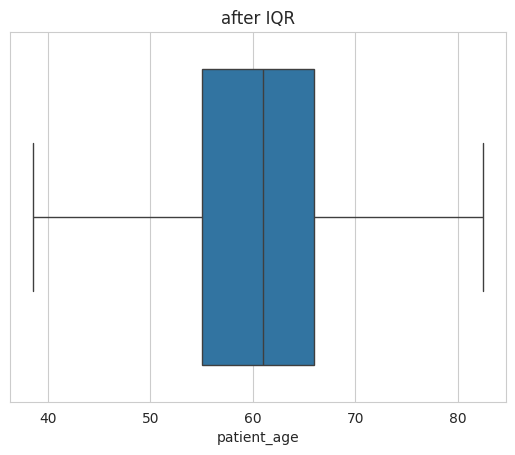

In [18]:
sns.boxplot(x=train_df["patient_age"])
plt.title("after IQR")
plt.show()

In [19]:
train_df["image_path"] = train_df["image_id"].apply(lambda x: os.path.join(TRAIN_IMG, f"{x}.jpg"))

In [20]:
print(train_df["image_path"].apply(os.path.exists).value_counts())

image_path
True    13015
Name: count, dtype: int64


In [21]:
train_df["diabetic_retinopathy"].value_counts().sort_index()

,count
diabetic_retinopathy,
0,12159
1,856


In [22]:
train_df["diabetic_retinopathy"].value_counts(normalize=True).sort_index()

,proportion
diabetic_retinopathy,
0,0.93423
1,0.06577


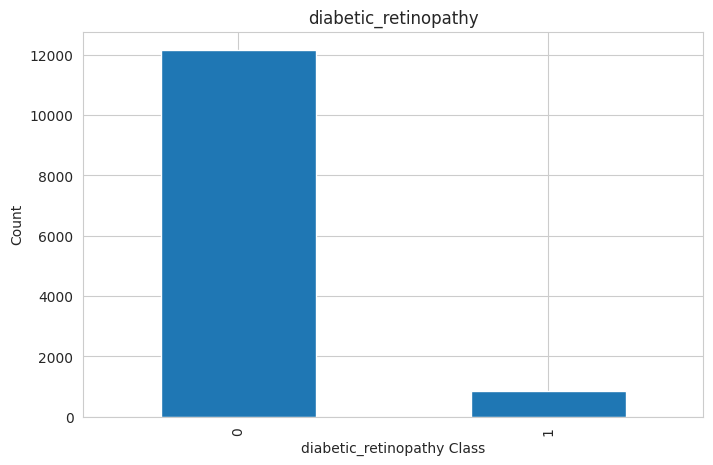

In [23]:
plt.figure(figsize=(8,5))
train_df["diabetic_retinopathy"].value_counts().sort_index().plot(kind="bar")
plt.title("diabetic_retinopathy")
plt.xlabel("diabetic_retinopathy Class")
plt.ylabel("Count")
plt.show()

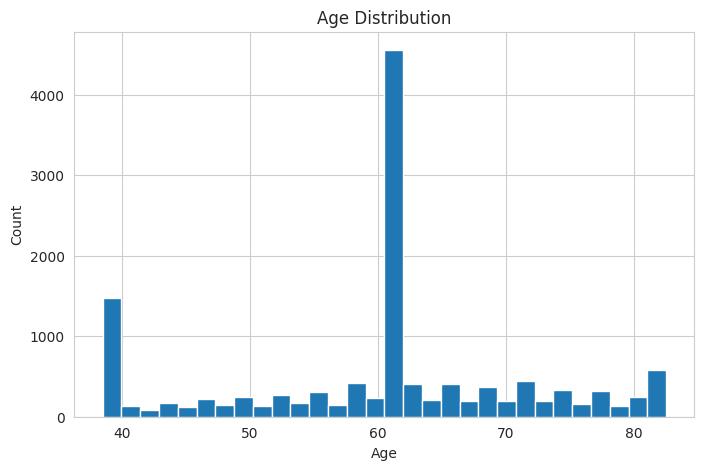

In [24]:
plt.figure(figsize=(8,5))
train_df["patient_age"].hist(bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

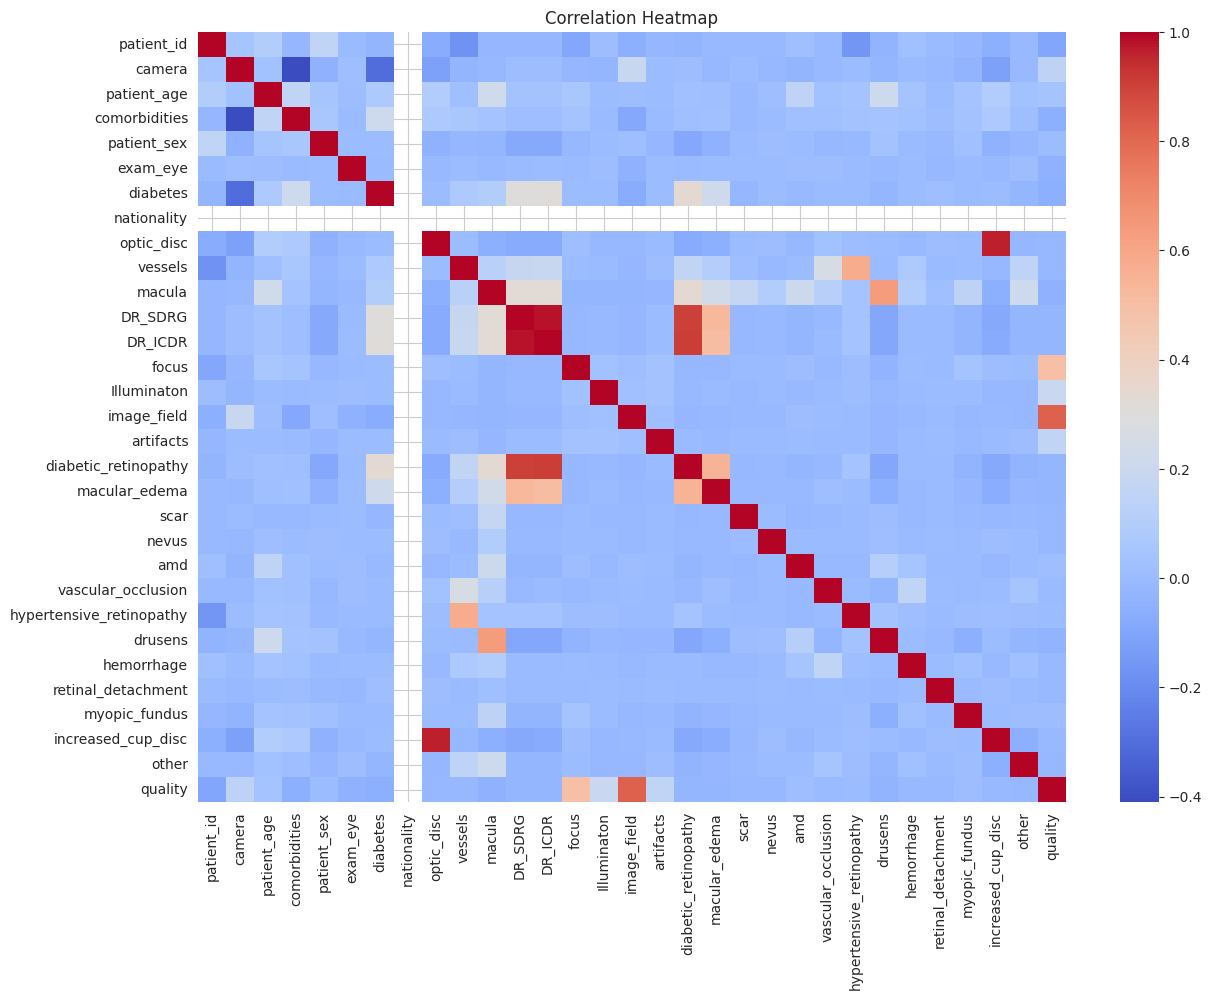

In [28]:
numeric_df = df_model.drop(columns=["image_id", "image_path"], errors="ignore")

plt.figure(figsize=(14,10))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

In [29]:
corr_with_target = numeric_df.corr()["diabetic_retinopathy"].sort_values(ascending=False)
corr_with_target

,diabetic_retinopathy
diabetic_retinopathy,1.000000
DR_ICDR,0.909921
DR_SDRG,0.903450
macular_edema,0.549366
diabetes,0.337802
macula,0.333693
vessels,0.159682
hypertensive_retinopathy,0.037102
patient_age,0.024234
comorbidities,0.018134


In [30]:
train_df["macular_edema"].value_counts(dropna=False)

,count
macular_edema,
0,12694
1,321


In [31]:
train_df["diabetic_retinopathy"].value_counts(dropna=False)

,count
diabetic_retinopathy,
0,12159
1,856


In [32]:
train_df["DR_SDRG"].value_counts(dropna=False)

,count
DR_SDRG,
0,12153
4,323
1,218
3,218
2,103


In [33]:
print("Unique patients in train:", train_df["patient_id"].nunique())

Unique patients in train: 6819


In [35]:
df_model = train_df.copy()

categorical_cols = df_model.select_dtypes(include=["object"]).columns.tolist()
categorical_cols = [col for col in categorical_cols if col not in ["image_id", "image_path"]]

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    label_encoders[col] = le

df_model.head()

,image_id,patient_id,camera,patient_age,comorbidities,patient_sex,exam_eye,diabetes,nationality,optic_disc,...,vascular_occlusion,hypertensive_retinopathy,drusens,hemorrhage,retinal_detachment,myopic_fundus,increased_cup_disc,other,quality,image_path
0,img00001,1,0,48.0,73,1,1,1,0,1,...,0,0,0,0,0,0,1,0,0,/content/Data/Data/Data/dataset_split/train/im...
1,img00002,1,0,48.0,73,1,2,1,0,2,...,0,0,0,0,0,0,1,0,0,/content/Data/Data/Data/dataset_split/train/im...
2,img00003,2,0,38.5,73,2,1,1,0,1,...,0,0,0,0,0,0,0,0,0,/content/Data/Data/Data/dataset_split/train/im...
3,img00004,2,0,38.5,73,2,2,1,0,1,...,0,0,0,0,0,0,0,0,0,/content/Data/Data/Data/dataset_split/train/im...
4,img00005,3,0,38.5,73,1,1,1,0,2,...,0,0,0,0,0,0,0,0,0,/content/Data/Data/Data/dataset_split/train/im...


In [57]:
target = "diabetic_retinopathy"

drop_cols = ["image_id", "image_path", "patient_id","DR_SDRG","DR_ICDR", target]
feature_cols = [col for col in df_model.columns if col not in drop_cols]

X = df_model[feature_cols]
y = df_model[target]

print("Number of features:", len(feature_cols))
print(feature_cols)

Number of features: 27
['camera', 'patient_age', 'comorbidities', 'patient_sex', 'exam_eye', 'diabetes', 'nationality', 'optic_disc', 'vessels', 'macula', 'focus', 'Illuminaton', 'image_field', 'artifacts', 'macular_edema', 'scar', 'nevus', 'amd', 'vascular_occlusion', 'hypertensive_retinopathy', 'drusens', 'hemorrhage', 'retinal_detachment', 'myopic_fundus', 'increased_cup_disc', 'other', 'quality']


In [58]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (10412, 27)
X_test shape: (2603, 27)
